# Error analysis

## Imports

In [1]:
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

from heart_failure.dataset import split_data
from heart_failure.config.modeling import MIN_RECALL
from heart_failure.config.config import INTERIM_DATA_DIR, HEART_DISEASE, SEX, MODELS_DIR, CHEST_PAIN_TYPE, ST_SLOPE
from heart_failure.modeling.evaluate import find_best_threshold
from heart_failure.modeling.predict import predict_by_threshold

2026-06-26 15:07:19.736 | INFO     | heart_failure.config.config:<module>:11 - PROJ_ROOT path is: D:\heart_failure


In [2]:
df = pd.read_csv(INTERIM_DATA_DIR / "heart.csv")

y = df[HEART_DISEASE]
X = df.drop(columns=[HEART_DISEASE])

X_train, y_train, X_val, y_val, X_test, y_test = split_data(
    X, y, stratify_func=lambda X, y: pd.concat([X[[SEX]], y], axis=1)
)

## Model prediction

In [3]:
with open(MODELS_DIR / "xgboost.pkl", "rb") as f:
    model = pickle.load(f)

fe_pipeline = model.named_steps["feature_engineering"]

In [4]:
X_val_transformed = fe_pipeline.transform(X_val)
y_val_proba = model.predict_proba(X_val)[:, 1]
best_threshold = find_best_threshold(y_val, y_val_proba, MIN_RECALL)
y_val_pred = predict_by_threshold(model, X_val, best_threshold)

### Confusion Matrix

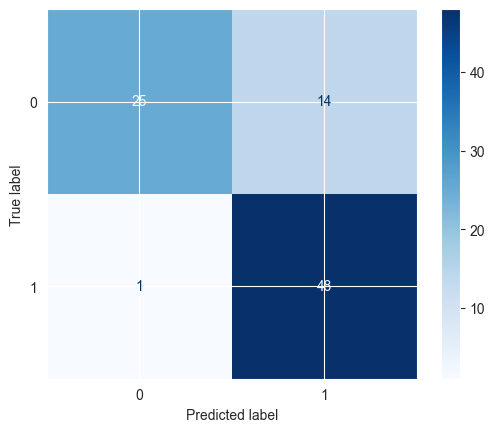

In [5]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred, cmap="Blues")
plt.show()

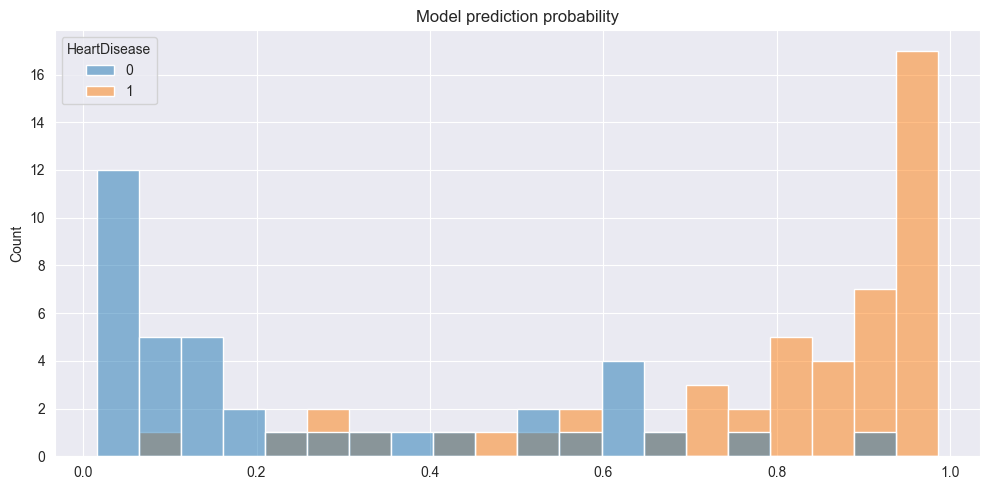

In [6]:
fig, axes = plt.subplots(figsize=(10, 5))

sns.histplot(X_val, x=y_val_proba, hue=y_val, ax=axes, bins=20)
axes.set_title(f"Model prediction probability")

plt.tight_layout()
plt.show()

I want to separately deal with cases that are classified too confidently (incorrectly) and those that are ambiguously classified incorrectly (close to 0.5).

## FP Analysis

In [7]:
negative = y_val == 0
strong_cl = negative & (y_val_proba >= 0.7)
X_val[strong_cl]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
188,50,F,ASY,120.0,328.0,0,Normal,110,Y,1.0,Flat
89,55,M,ASY,140.0,229.0,0,Normal,110,Y,0.5,Flat


In [8]:
X_val_transformed[strong_cl]

,target_encoder__RestingECG,target_encoder__ChestPainType,target_encoder__ST_Slope,binarizer__Age,binarizer__Cholesterol,binarizer__MaxHR,binary_encoder__Sex,binary_encoder__FastingBS,binary_encoder__ExerciseAngina,remainder__RestingBP,remainder__Oldpeak
188,0.521817,0.795385,0.839519,3.0,9.0,1.0,0.0,0.0,1.0,120.0,1.0
89,0.521817,0.795385,0.839519,5.0,3.0,1.0,1.0,0.0,1.0,140.0,0.5


All features seem to point to disease. In both cases St_Slope=Flat, CPT=ASY.

In [15]:
weak_cl = negative & (y_val_proba < 0.7) & (y_val_proba >= 0.5)
X_val[weak_cl]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
843,52,M,TA,118.0,186.0,0,LVH,190,N,0.0,Flat
252,61,M,ASY,125.0,292.0,0,ST,115,Y,0.0,Up
625,53,M,ASY,142.0,226.0,0,LVH,111,Y,0.0,Up
54,52,F,ASY,130.0,180.0,0,Normal,140,Y,1.5,Flat
782,45,F,ASY,138.0,236.0,0,LVH,152,Y,0.2,Flat
685,57,F,ASY,120.0,354.0,0,Normal,163,Y,0.6,Up
586,37,M,NAP,118.0,240.0,0,LVH,165,N,1.0,Flat
802,62,F,ASY,140.0,394.0,0,LVH,157,N,1.2,Flat


In [10]:
X_val_transformed[weak_cl]

,target_encoder__RestingECG,target_encoder__ChestPainType,target_encoder__ST_Slope,binarizer__Age,binarizer__Cholesterol,binarizer__MaxHR,binary_encoder__Sex,binary_encoder__FastingBS,binary_encoder__ExerciseAngina,remainder__RestingBP,remainder__Oldpeak
843,0.566813,0.415690,0.839519,4.0,1.0,9.0,1.0,0.0,0.0,118.0,0.0
252,0.629347,0.795385,0.182937,7.0,8.0,2.0,1.0,0.0,1.0,125.0,0.0
625,0.566813,0.795385,0.182937,4.0,3.0,1.0,1.0,0.0,1.0,142.0,0.0
54,0.521817,0.795385,0.839519,4.0,0.0,5.0,0.0,0.0,1.0,130.0,1.5
782,0.566813,0.795385,0.839519,2.0,5.0,7.0,0.0,0.0,1.0,138.0,0.2
685,0.521817,0.795385,0.182937,6.0,9.0,8.0,0.0,0.0,1.0,120.0,0.6
586,0.566813,0.376953,0.839519,0.0,5.0,8.0,1.0,0.0,0.0,118.0,1.0
802,0.566813,0.795385,0.839519,8.0,9.0,7.0,0.0,0.0,0.0,140.0,1.2


There are also many cases with ST_Slope=Flat. Its target encoding is 0.83. Perhaps because of this, the result is almost always classified as class 1.

There are also several cases where Oldpeak=0, St_Slope=Up, but the result is still 1. Is this because of CPT, EA, MaxHR?

It is also clear that in half of the cases the female gender is represented, although in the original distribution there are much fewer of them.

It's worth considering the following:
- When is the class value 0 when ST_Slope=Flat?
- What is the percentage of disease with EA=Y, Oldpeak=0?
- What to do with the misclassification of women?

The red flag so far is the last question.

### Female misclassification

First, I'm interested in ChestPainType and ST_Slope. Perhaps the problem is the different percentage of the class for women and men.

In [11]:
y_train.groupby([X_train[CHEST_PAIN_TYPE], X_train[SEX]]).mean()

ChestPainType  Sex
ASY            F      0.562500
               M      0.834483
ATA            F      0.046512
               M      0.185185
NAP            F      0.131579
               M      0.459459
TA             F      0.142857
               M      0.481481
Name: HeartDisease, dtype: float64

In [12]:
y_train.groupby([X_train[ST_SLOPE], X_train[SEX]]).mean()

ST_Slope  Sex
Down      F      1.000000
          M      0.783784
Flat      F      0.538462
          M      0.897436
Up        F      0.049383
          M      0.236181
Name: HeartDisease, dtype: float64

The percentages are completely different.